In [ ]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["TotalCharges"].dtype

dtype('O')

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df["TotalCharges"].dtype

dtype('float64')

In [ ]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [ ]:
df = df.dropna(subset=["TotalCharges"])

In [ ]:
df.shape

(7032, 21)

In [ ]:
df.to_csv("Telco_Customer_Churn_Cleaned.csv", index=False)

In [ ]:
import sqlite3

conn = sqlite3.connect("customer_churn.db")

df.to_sql(
    "customer_churn",
    conn,
    if_exists="replace",
    index=False
)

7032

In [ ]:
pd.read_sql(
    "SELECT * FROM customer_churn LIMIT 5",
    conn
)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
pd.read_sql("""
SELECT COUNT(*) AS Total_Customers
FROM customer_churn;
""", conn)

,Total_Customers
0,7032


In [ ]:
pd.read_sql("""
SELECT
ROUND(
100.0 * SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2
) AS Churn_Rate
FROM customer_churn;
""", conn)

,Churn_Rate
0,26.58


In [ ]:
pd.read_sql("""
SELECT
Contract,
COUNT(*) AS Customers,
SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS Churned_Customers,
ROUND(
100.0 * SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2
) AS Churn_Rate
FROM customer_churn
GROUP BY Contract
ORDER BY Churn_Rate DESC;
""", conn)

,Contract,Customers,Churned_Customers,Churn_Rate
0,Month-to-month,3875,1655,42.71
1,One year,1472,166,11.28
2,Two year,1685,48,2.85


In [ ]:
pd.read_sql("""
SELECT
PaymentMethod,
COUNT(*) AS Customers,
SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS Churned_Customers,
ROUND(
100.0 * SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2
) AS Churn_Rate
FROM customer_churn
GROUP BY PaymentMethod
ORDER BY Churn_Rate DESC;
""", conn)

,PaymentMethod,Customers,Churned_Customers,Churn_Rate
0,Electronic check,2365,1071,45.29
1,Mailed check,1604,308,19.20
2,Bank transfer (automatic),1542,258,16.73
3,Credit card (automatic),1521,232,15.25


In [ ]:
pd.read_sql("""
SELECT
ROUND(SUM(TotalCharges),2) AS Revenue_Lost
FROM customer_churn
WHERE Churn='Yes';
""", conn)

,Revenue_Lost
0,2862926.9


In [ ]:
pd.read_sql("""
SELECT
Contract,
ROUND(AVG(MonthlyCharges),2) AS Avg_Monthly_Charges
FROM customer_churn
GROUP BY Contract
ORDER BY Avg_Monthly_Charges DESC;
""", conn)

,Contract,Avg_Monthly_Charges
0,Month-to-month,66.40
1,One year,65.08
2,Two year,60.87


In [ ]:
pd.read_sql("""
SELECT
ROUND(AVG(tenure),2) AS Avg_Tenure_Churned
FROM customer_churn
WHERE Churn='Yes';
""", conn)

,Avg_Tenure_Churned
0,17.98


In [ ]:
pd.read_sql("""
SELECT
InternetService,
COUNT(*) AS Customers,
SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS Churned,
ROUND(
100.0*SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2
) AS Churn_Rate
FROM customer_churn
GROUP BY InternetService
ORDER BY Churn_Rate DESC;
""", conn)

,InternetService,Customers,Churned,Churn_Rate
0,Fiber optic,3096,1297,41.89
1,DSL,2416,459,19.00
2,No,1520,113,7.43


In [ ]:
pd.read_sql("""
SELECT
SeniorCitizen,
COUNT(*) AS Customers,
SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS Churned,
ROUND(
100.0*SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2
) AS Churn_Rate
FROM customer_churn
GROUP BY SeniorCitizen;
""", conn)

,SeniorCitizen,Customers,Churned,Churn_Rate
0,0,5890,1393,23.65
1,1,1142,476,41.68


In [ ]:
pd.read_sql("""
SELECT
gender,
COUNT(*) AS Customers,
SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS Churned,
ROUND(
100.0*SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2
) AS Churn_Rate
FROM customer_churn
GROUP BY gender;
""", conn)

,gender,Customers,Churned,Churn_Rate
0,Female,3483,939,26.96
1,Male,3549,930,26.20


In [ ]:
pd.read_sql("""
WITH ContractStats AS (
SELECT
Contract,
ROUND(
100.0*SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2
) AS Churn_Rate
FROM customer_churn
GROUP BY Contract
)
SELECT *,
RANK() OVER(ORDER BY Churn_Rate DESC) AS Churn_Rank
FROM ContractStats;
""", conn)

,Contract,Churn_Rate,Churn_Rank
0,Month-to-month,42.71,1
1,One year,11.28,2
2,Two year,2.85,3


In [ ]:
pd.read_sql("""
SELECT
customerID,
Contract,
MonthlyCharges,
TotalCharges
FROM customer_churn
WHERE Churn='Yes'
ORDER BY TotalCharges DESC
LIMIT 10;
""", conn)

,customerID,Contract,MonthlyCharges,TotalCharges
0,2889-FPWRM,One year,117.80,8684.80
1,0201-OAMXR,One year,115.55,8127.60
2,3886-CERTZ,One year,109.25,8109.80
3,1444-VVSGW,One year,115.65,7968.85
4,5271-YNWVR,Two year,113.15,7856.00
5,8199-ZLLSA,One year,118.35,7804.15
6,9053-JZFKV,Two year,116.20,7752.30
7,1555-DJEQW,Two year,114.20,7723.90
8,3259-FDWOY,Two year,106.00,7723.70
9,7317-GGVPB,Two year,108.60,7690.90


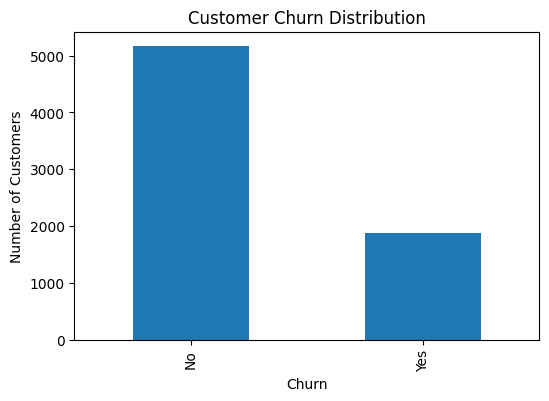

In [ ]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Customer Churn Distribution"
)
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

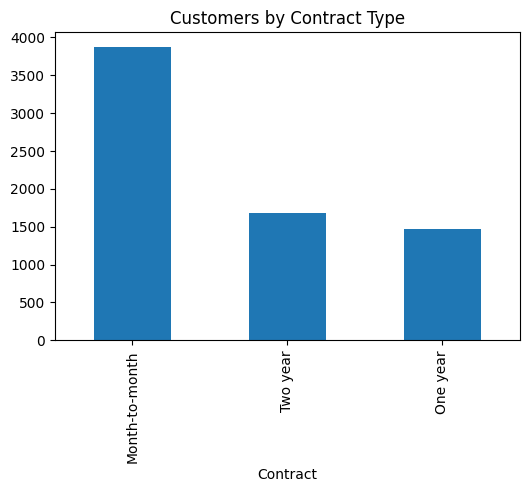

In [ ]:
df["Contract"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Customers by Contract Type"
)
plt.show()

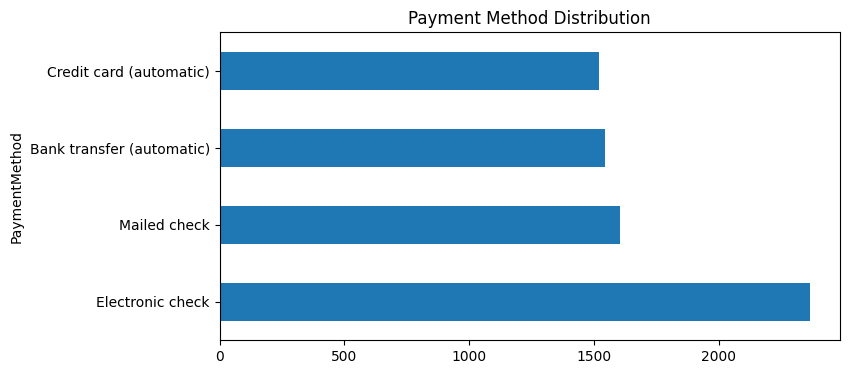

In [ ]:
df["PaymentMethod"].value_counts().plot(
    kind="barh",
    figsize=(8,4),
    title="Payment Method Distribution"
)
plt.show()

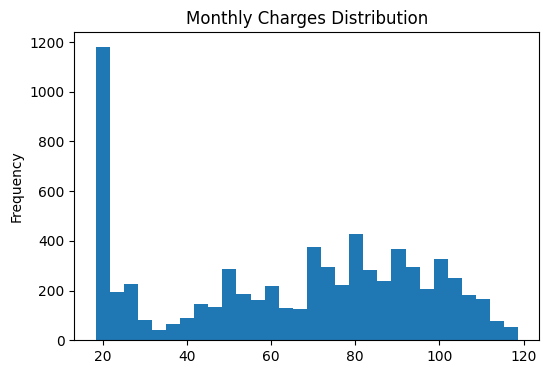

In [ ]:
df["MonthlyCharges"].plot(
    kind="hist",
    bins=30,
    figsize=(6,4),
    title="Monthly Charges Distribution"
)
plt.show()

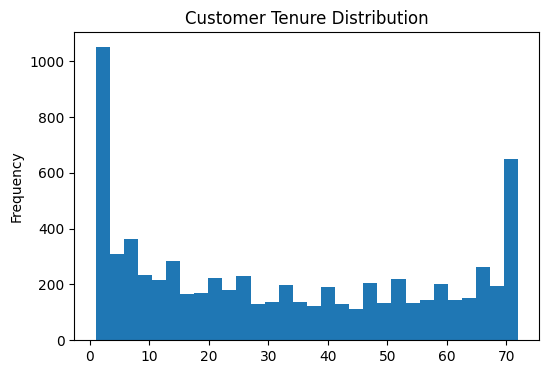

In [ ]:
df["tenure"].plot(
    kind="hist",
    bins=30,
    figsize=(6,4),
    title="Customer Tenure Distribution"
)
plt.show()

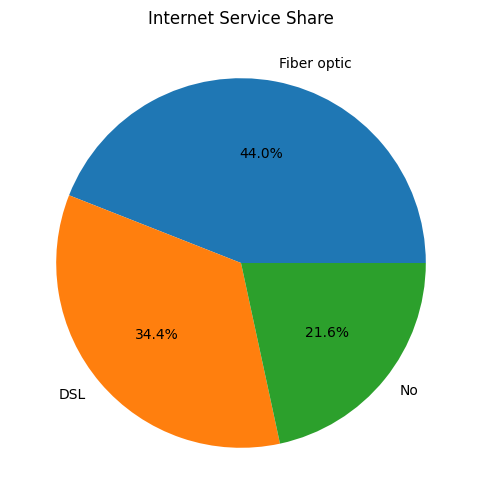

In [ ]:
df["InternetService"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6),
    title="Internet Service Share"
)
plt.ylabel("")
plt.show()

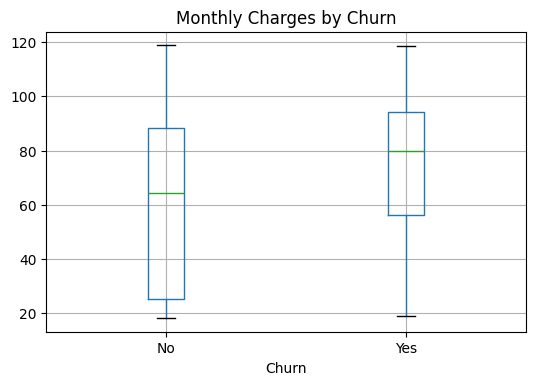

In [ ]:
df.boxplot(column="MonthlyCharges", by="Churn", figsize=(6,4))
plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.show()

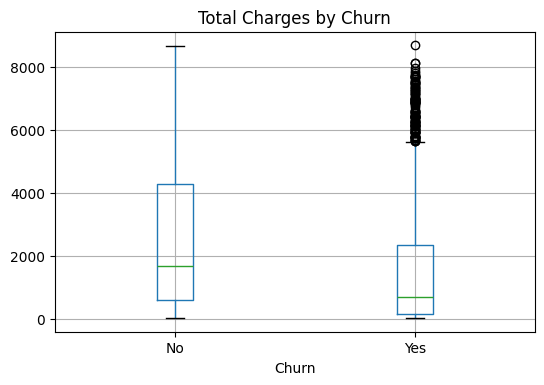

In [ ]:
df.boxplot(column="TotalCharges", by="Churn", figsize=(6,4))
plt.title("Total Charges by Churn")
plt.suptitle("")
plt.show()

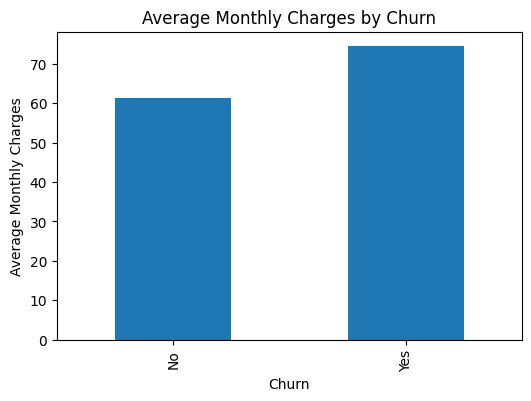

In [ ]:
df.groupby("Churn")["MonthlyCharges"].mean().plot(
    kind="bar",
    figsize=(6,4),
    title="Average Monthly Charges by Churn"
)
plt.ylabel("Average Monthly Charges")
plt.show()

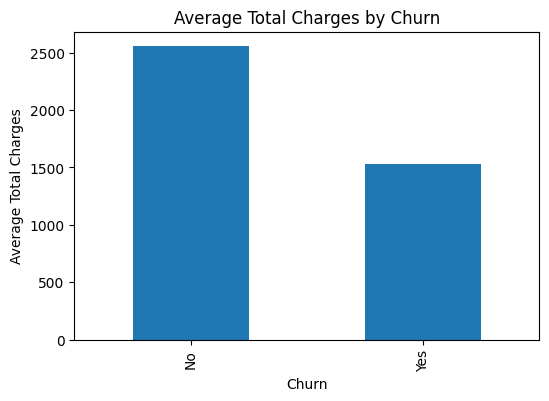

In [ ]:
df.groupby("Churn")["TotalCharges"].mean().plot(
    kind="bar",
    figsize=(6,4),
    title="Average Total Charges by Churn"
)
plt.ylabel("Average Total Charges")
plt.show()

In [ ]:
df.to_csv("Telco_Customer_Churn_Cleaned.csv", index=False)

In [ ]:
df["customerID"].nunique()

7032

In [ ]:
# Total Customers
total_customers = len(df)

# Churned Customers
churned_customers = len(df[df["Churn"] == "Yes"])

# Active Customers
active_customers = len(df[df["Churn"] == "No"])

# Churn Rate
churn_rate = round((churned_customers / total_customers) * 100, 2)

# Total Revenue
total_revenue = round(df["TotalCharges"].sum(), 2)

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Active Customers:", active_customers)
print("Churn Rate:", churn_rate, "%")
print("Total Revenue:", total_revenue)

Total Customers: 7032
Churned Customers: 1869
Active Customers: 5163
Churn Rate: 26.58 %
Total Revenue: 16056168.7


**ML**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

df.shape

df.isnull().sum()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

/tmp/ipykernel_602/3609252841.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(


In [ ]:
df.drop("customerID", axis=1, inplace=True)

In [ ]:
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [ ]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype=="object":
        df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train,y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
print("Accuracy :",accuracy_score(y_test,y_pred_dt))

print("Precision :",precision_score(y_test,y_pred_dt))

print("Recall :",recall_score(y_test,y_pred_dt))

print("F1 :",f1_score(y_test,y_pred_dt))

print("ROC AUC :",roc_auc_score(y_test,y_pred_dt))

Accuracy : 0.7253371185237757
Precision : 0.48214285714285715
Recall : 0.5067024128686327
F1 : 0.49411764705882355
ROC AUC : 0.6553782334613435


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
print("Accuracy :",accuracy_score(y_test,y_pred_rf))

print("Precision :",precision_score(y_test,y_pred_rf))

print("Recall :",recall_score(y_test,y_pred_rf))

print("F1 :",f1_score(y_test,y_pred_rf))

print("ROC AUC :",roc_auc_score(y_test,y_pred_rf))

Accuracy : 0.7977288857345636
Precision : 0.664179104477612
Recall : 0.4772117962466488
F1 : 0.5553822152886115
ROC AUC : 0.6951696046870309


In [ ]:
comparison = pd.DataFrame({

"Model":[
"Logistic Regression",
"Decision Tree",
"Random Forest"
],

"Accuracy":[
accuracy_score(y_test,y_pred_lr),
accuracy_score(y_test,y_pred_dt),
accuracy_score(y_test,y_pred_rf)
],

"Precision":[
precision_score(y_test,y_pred_lr),
precision_score(y_test,y_pred_dt),
precision_score(y_test,y_pred_rf)
],

"Recall":[
recall_score(y_test,y_pred_lr),
precision_score(y_test,y_pred_dt),
recall_score(y_test,y_pred_rf)
],

"F1":[
f1_score(y_test,y_pred_lr),
f1_score(y_test,y_pred_dt),
f1_score(y_test,y_pred_rf)
],

"ROC_AUC":[
roc_auc_score(y_test,y_pred_lr),
roc_auc_score(y_test,y_pred_dt),
roc_auc_score(y_test,y_pred_rf)
]

})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.816182,0.680380,0.576408,0.624093,0.739459
1,Decision Tree,0.725337,0.482143,0.482143,0.494118,0.655378
2,Random Forest,0.797729,0.664179,0.477212,0.555382,0.695170


In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm)

[[946  90]
 [195 178]]


In [ ]:
print(
classification_report(
y_test,
y_pred_rf
)
)

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.48      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409



In [ ]:
importance = pd.DataFrame({

"Feature":X.columns,

"Importance":rf.feature_importances_

})

importance = importance.sort_values(
by="Importance",
ascending=False
)

importance

,Feature,Importance
18,TotalCharges,0.189999
17,MonthlyCharges,0.177173
4,tenure,0.159561
14,Contract,0.077461
16,PaymentMethod,0.050327
8,OnlineSecurity,0.047975
11,TechSupport,0.040406
0,gender,0.027588
9,OnlineBackup,0.026792
7,InternetService,0.026275


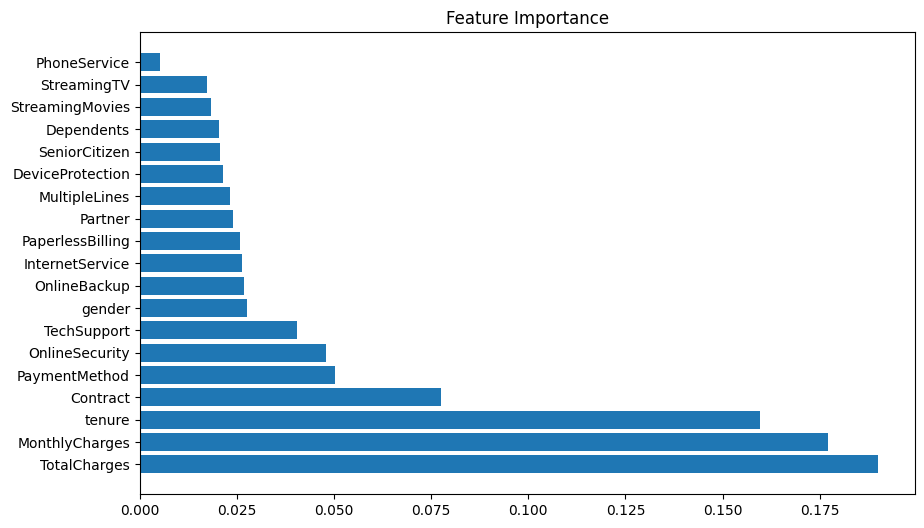

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
importance["Feature"],
importance["Importance"]
)

plt.title("Feature Importance")

plt.show()

In [ ]:
results = pd.DataFrame({

"Actual":y_test,

"Predicted":y_pred_rf

})

results.head(15)

,Actual,Predicted
185,1,1
2715,0,0
3825,0,0
1807,1,1
132,0,0
1263,1,0
3732,0,0
1672,0,0
811,1,0
2526,1,0


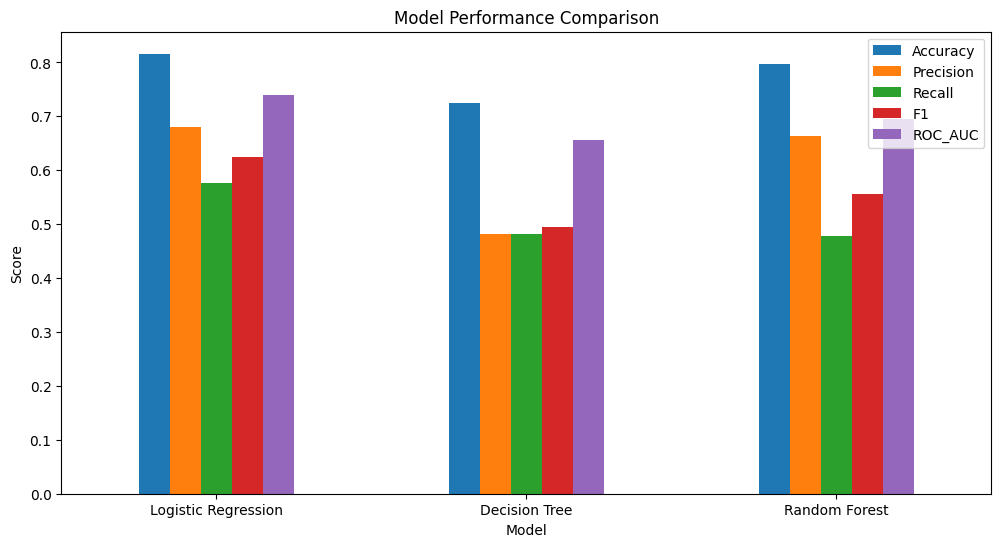

In [ ]:
comparison.plot(
    x="Model",
    y=["Accuracy","Precision","Recall","F1","ROC_AUC"],
    kind="bar",
    figsize=(12,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

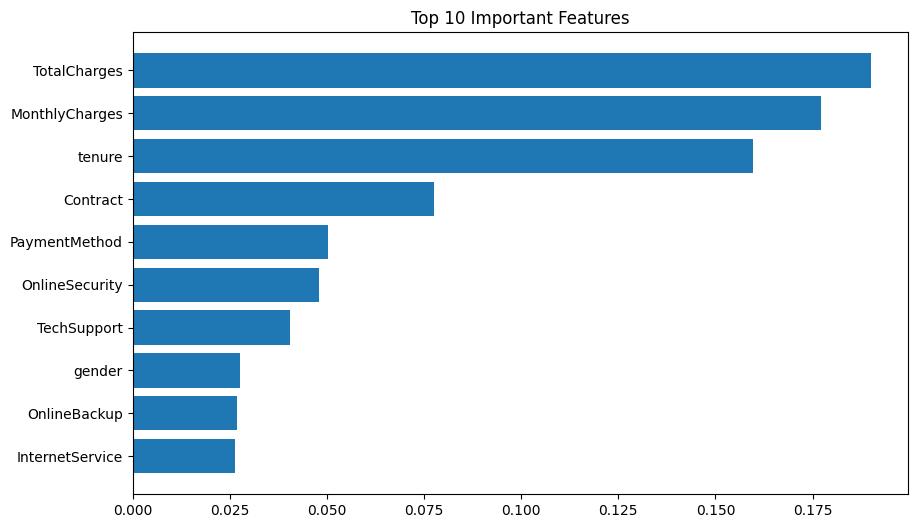

In [ ]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

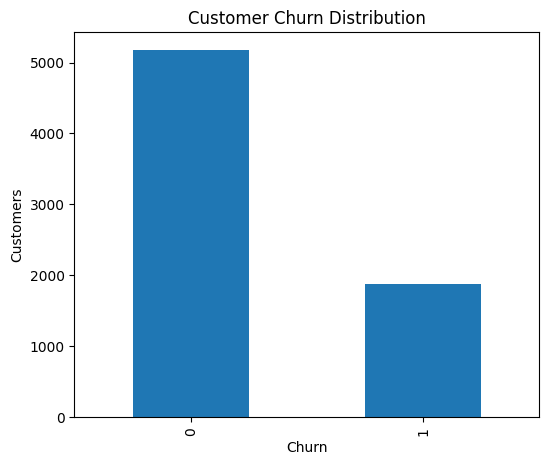

In [ ]:
df["Churn"].value_counts().plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Customer Churn Distribution")

plt.xlabel("Churn")

plt.ylabel("Customers")

plt.show()

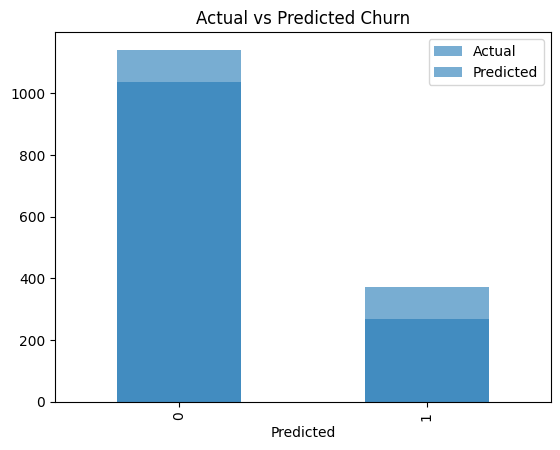

In [ ]:
results["Actual"].value_counts().plot(
    kind="bar",
    alpha=0.6,
    label="Actual"
)

results["Predicted"].value_counts().plot(
    kind="bar",
    alpha=0.6,
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted Churn")

plt.show()

Class 0 (No Churn)

Precision = 83%

Recall = 91%

Excellent
Class 1 (Churn)

Precision = 66%

Recall = 48%

1. Logistic Regression achieved the best overall performance with an accuracy of 81.6%.

2. Contract type, tenure and monthly charges were among the most influential factors affecting customer churn.

3. The model identified non-churn customers very effectively while showing moderate performance in detecting churn customers.

4. These predictions can help telecom companies prioritize retention campaigns for customers at higher risk of churning.

5. Predictive analytics can reduce customer attrition and improve long-term customer lifetime value.

Three machine learning models were developed and compared for customer churn prediction.

Among them, Logistic Regression achieved the strongest overall performance with an accuracy of 81.6% and the highest ROC-AUC score.

The project demonstrates how predictive analytics can support proactive customer retention by identifying customers who are more likely to churn.